In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [10]:
df = pd.read_csv("../data/Accepted.csv", low_memory=False)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1048575, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 1.2+ GB


In [12]:
missing = df.isnull().sum().sort_values(ascending=False)

missing.head(20)

member_id                                     1048575
desc                                          1048518
orig_projected_additional_accrued_interest    1043693
hardship_end_date                             1042463
hardship_loan_status                          1042463
hardship_start_date                           1042463
hardship_status                               1042463
payment_plan_start_date                       1042463
hardship_length                               1042463
hardship_dpd                                  1042463
hardship_payoff_balance_amount                1042463
deferral_term                                 1042463
hardship_last_payment_amount                  1042463
hardship_reason                               1042463
hardship_type                                 1042463
hardship_amount                               1042463
sec_app_mths_since_last_major_derog           1030351
settlement_term                               1029866
debt_settlement_flag_date   

In [13]:
df["loan_status"].value_counts()

loan_status
Fully Paid            482595
Current               419550
Charged Off           129187
Late (31-120 days)     10879
In Grace Period         4227
Late (16-30 days)       2104
Default                   21
Name: count, dtype: int64

In [14]:
bad = ["Charged Off","Default"]
good = ["Fully Paid","Current"]

df["is_bad"] = df["loan_status"].apply(
    lambda x: 1 if x in bad else (0 if x in good else None)
)

df["is_bad"].value_counts()

is_bad
0.0    902145
1.0    129208
Name: count, dtype: int64

In [15]:
default_rate = df["is_bad"].mean()

print("Default Rate:", round(default_rate*100,2), "%")

Default Rate: 12.53 %


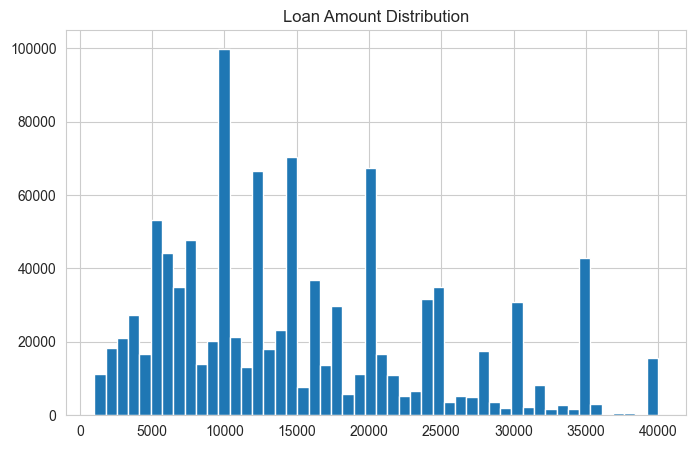

In [16]:
plt.figure(figsize=(8,5))

df["loan_amnt"].hist(bins=50)

plt.title("Loan Amount Distribution")

plt.show()

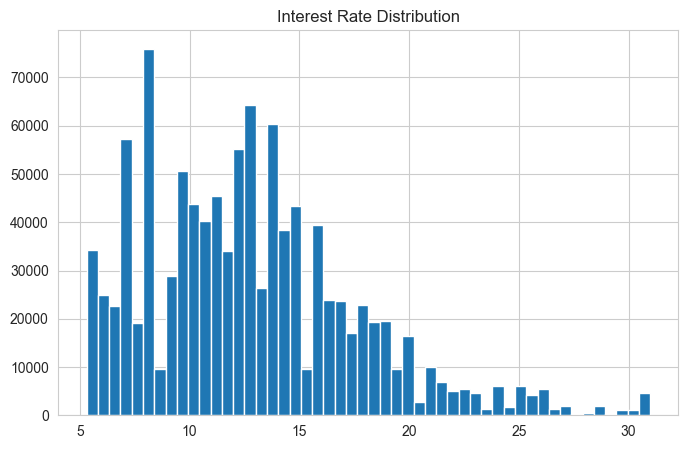

In [17]:
df["int_rate"] = df["int_rate"].astype(str).str.replace("%","").astype(float)

plt.figure(figsize=(8,5))

df["int_rate"].hist(bins=50)

plt.title("Interest Rate Distribution")

plt.show()

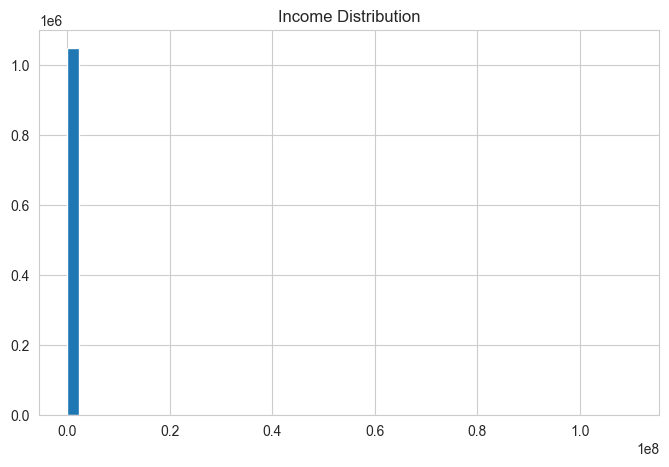

In [18]:
df["annual_inc"] = df["annual_inc"].astype(str).str.replace(",","").astype(float)

plt.figure(figsize=(8,5))

df["annual_inc"].hist(bins=50)

plt.title("Income Distribution")

plt.show()

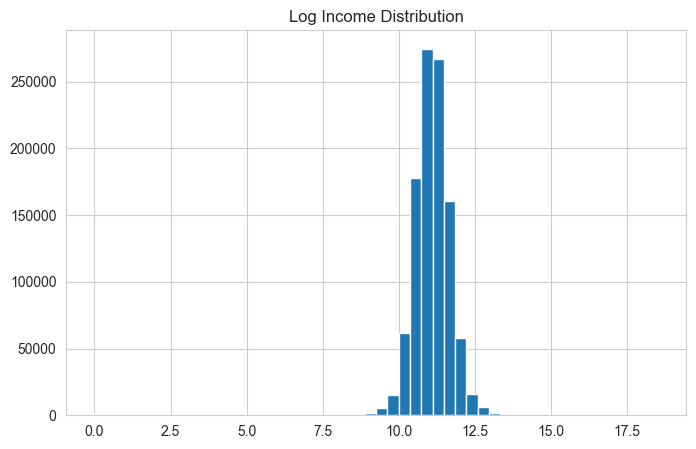

In [19]:
df["log_income"] = np.log1p(df["annual_inc"])

plt.figure(figsize=(8,5))

df["log_income"].hist(bins=50)

plt.title("Log Income Distribution")

plt.show()

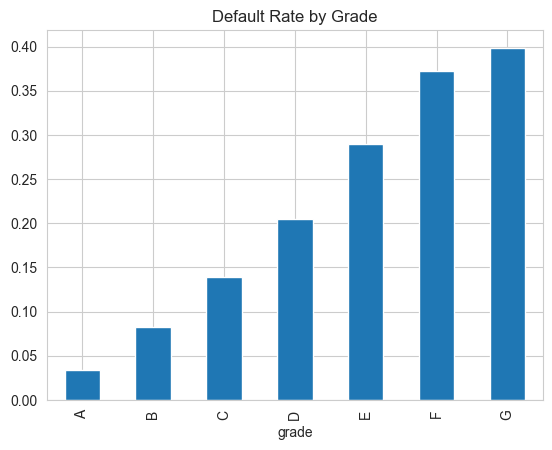

In [20]:
grade_default = df.groupby("grade")["is_bad"].mean()

grade_default.plot(kind="bar")

plt.title("Default Rate by Grade")

plt.show()

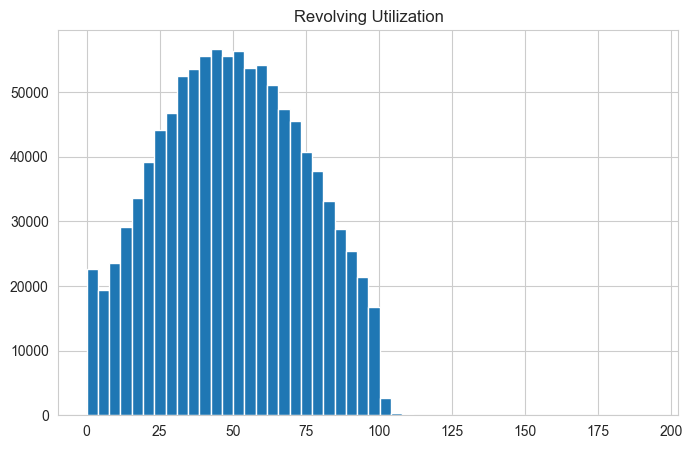

In [21]:
df["revol_util"] = df["revol_util"].astype(str).str.replace("%","").astype(float)

plt.figure(figsize=(8,5))

df["revol_util"].hist(bins=50)

plt.title("Revolving Utilization")

plt.show()

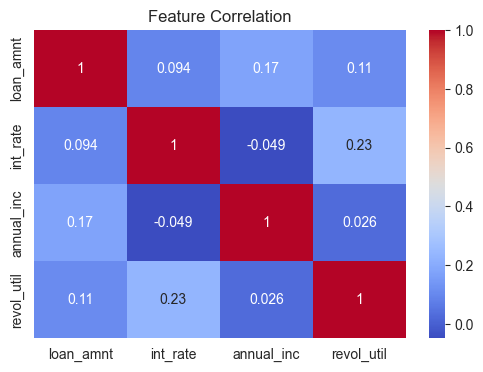

In [22]:
features = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "revol_util"
]

corr = df[features].corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

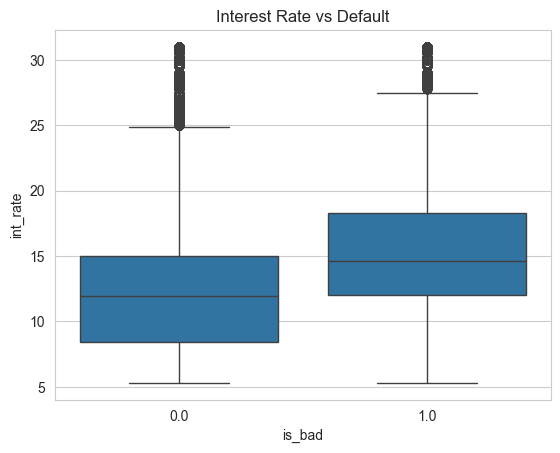

In [23]:
sns.boxplot(x="is_bad", y="int_rate", data=df)

plt.title("Interest Rate vs Default")

plt.show()